In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


# Load customer-level data
customers = pd.read_csv('../data/raw/customers.csv')

customers.head()



,customer_id,first_name,last_name,email,phone,city,signup_date,age,gender,total_trips,cancelled_trips,days_since_last_trip,churned,engagement_score,loyalty_score,persona,signup_channel,income_level,payment_method,device_type
0,CUST00000,Adrian,Walker,adrian.walker@gmail.com,020 7946 0251,London,27/04/2024,19,Other,63,7,20,0,1.0,0.994,Tourist,Ads,high,Debit Card,iOS
1,CUST00001,Tony,Jones,tony.jones@hotmail.co.uk,4.41165E+11,London,01/10/2023,61,Other,52,0,44,0,1.0,0.925,Business,Partnership,high,Credit Card,iOS
2,CUST00002,Lynn,Carter,lynn.carter@outlook.com,+44(0)20 7496 0628,London,22/01/2025,31,Male,47,1,4,0,1.0,0.894,Business,Ads,high,Cash,iOS
3,CUST00003,Marcelo,Madrigal,marcelo.madrigal@hotmail.com,+34987 210 730,Barcelona,01/03/2025,55,Female,44,3,7,0,1.0,0.875,Business,Ads,low,Cash,Android
4,CUST00004,Faye,Strik,faye.strik@hotmail.com,086 1284110,Amsterdam,13/09/2025,27,Male,30,2,33,0,1.0,0.787,Tourist,Referral,medium,Credit Card,Android


In [ ]:
customers.columns

Index(['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city',
       'signup_date', 'age', 'gender', 'total_trips', 'cancelled_trips',
       'days_since_last_trip', 'churned', 'engagement_score', 'loyalty_score',
       'persona', 'signup_channel', 'income_level', 'payment_method',
       'device_type'],
      dtype='object')

In [4]:
segmentation_features = customers[["total_trips","cancelled_trips","days_since_last_trip","engagement_score","loyalty_score"]].copy()
segmentation_features.head()

,total_trips,cancelled_trips,days_since_last_trip,engagement_score,loyalty_score
0,63,7,20,1.0,0.994
1,52,0,44,1.0,0.925
2,47,1,4,1.0,0.894
3,44,3,7,1.0,0.875
4,30,2,33,1.0,0.787


In [7]:
segmentation_features.isna().sum()

total_trips             0
cancelled_trips         0
days_since_last_trip    0
engagement_score        0
loyalty_score           0
dtype: int64

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(segmentation_features)

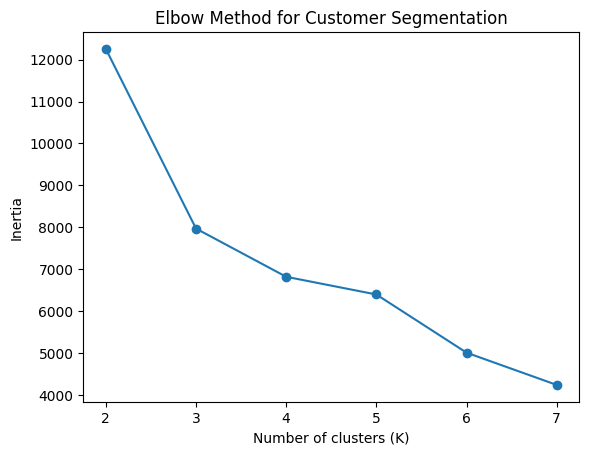

In [10]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
plt.plot(range(2, 8), inertia, marker='o')
plt.title('Elbow Method for Customer Segmentation')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Customer Segmentation')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
customers['segment'] = kmeans.fit_predict(scaled_features)  

In [12]:
customers["segment"].value_counts()

segment
1    1726
2    1244
0      30
Name: count, dtype: int64

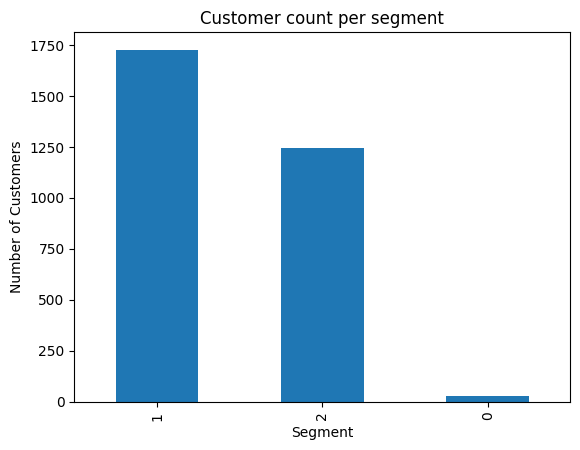

In [13]:
customers["segment"].value_counts().plot(kind='bar' )
plt.title('Customer count per segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

In [15]:
segments_profile=customers.groupby('segment')[[
    "total_trips",
    "cancelled_trips",
    "days_since_last_trip",
    "engagement_score",
    "loyalty_score",
    "churned"]].mean()
segments_profile

,total_trips,cancelled_trips,days_since_last_trip,engagement_score,loyalty_score,churned
segment,,,,,,
0,13.433333,1.700000,40.433333,0.944800,0.650800,0.333333
1,32.902665,1.982039,21.353998,0.999739,0.805423,0.183662
2,55.876206,4.695338,20.620579,1.000000,0.936966,0.178457


Text(0.5, 1.0, 'Customer Segments based on Total Trips and Days Since Last Trip')

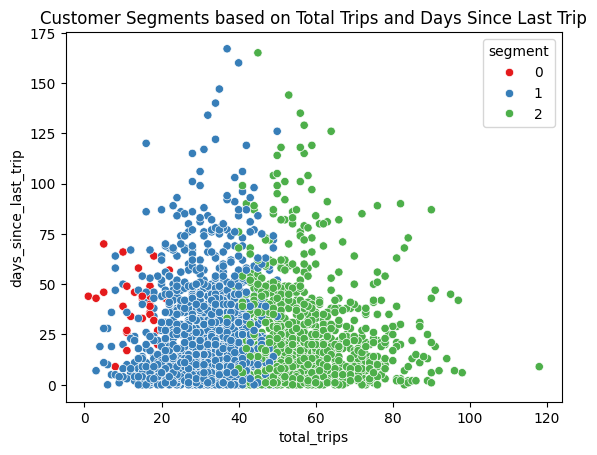

In [16]:
sns.scatterplot(data=customers, x="total_trips", y="days_since_last_trip", hue="segment", palette="Set1")
plt.title('Customer Segments based on Total Trips and Days Since Last Trip')